## Your Name: ADITI JAIN
## The project I attempted was: (3) Text
(please delete as appropriate)

# CSC8111 Coursework Specification

For this coursework you will perform **THREE** short questions which cover the breadth of the machine learning module along with attempting **ONE** of the four longer project-style questions. All of the short tasks and longer project-style questions can be found in this notebook. You should provide all of your answers in this notebook and submit it to Canvas before the submission deadline.

The learning objectives of these short questions are:
- To demonstrate a wide-range of machine learning skills.
- To be able to apply the most appropriate approach at the right time.



---
## Question 1: Classification (10 marks)

Load the dataset below, where X and y are the feature (input) variables and target (output) variable. Based on this dataset, build TWO classifiers using different machine learning approaches to predict the two classes in the target variable. You are free to use any appropriate machine learning models and libraries, but you need to split the dataset into training and test sets and optimise the model's hyperparameters (e.g. using GridSearchCV()). As a result, the performance metrics of the best classifier should be reported over the test set. Please follow the steps below to complete the code.

The dataset is available at:
https://ncl.instructure.com/courses/53509/files/7659751?wrap=1 and
https://ncl.instructure.com/courses/53509/files/7659755?wrap=1


## Set up the environment and load the dataset

In [20]:
# just run this cell, don't change the code
import numpy as np
from numpy import loadtxt
X = loadtxt('cls_X.csv', delimiter=',')
y = loadtxt('cls_y.csv', delimiter=',')

## Q1.1 Split the data into training and test sets (20% for testing)

In [21]:
# write your code below to replace the ellipsis "..."
! pip install scikit-learn pandas tensorflow

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [23]:
#splitting data into test and train, test_size =0.2 denote 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=6)

## Q1.2 Create your first classifier

#### Q1.2.1 First, make an attempt by using an appropriate machine learning method without optimising the hyperparameter(s). Report the model accuracy over the test set (i.e. test accuracy).

In [24]:
# write your code below to replace the ellipsis "..."
#Random Forest Classifier without tuning hyper parameters
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
classifier_rf = RandomForestClassifier()
classifier_rf.fit(X_train,y_train)
predict_rf = classifier_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, predict_rf)
#printing accuracy
print("Random Forest without hyperparameters Accuracy:", accuracy_rf)


Random Forest without hyperparameters Accuracy: 0.8625


#### Q1.2.2 Then, optimise the hyperparameter(s) using the same machine learning method as above. Report the best hyperparameter(s) and, use it to make your first classifier and print out its test accuracy.

In [25]:
# write your code below to replace the ellipsis "..."
#Random Forest Classifier with hyperparameters
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
#Tune the hyperparamers
param_grid_rf = dict(max_depth=[8,9,10,11],n_estimators = [30, 50, 100])
classifier_rf_hp = RandomForestClassifier()
grid_search_rf = GridSearchCV(classifier_rf_hp,param_grid=param_grid_rf,cv=5,scoring="f1",verbose=0,n_jobs=4)
grid_search_rf.fit(X_train,y_train)
# Print the values of the parameters chosen by grid search
estimator_rf = grid_search_rf.best_estimator_
print("Chosen max depth: {0}".format(estimator_rf.max_depth))
print("Chosen number of trees: {0}".format(estimator_rf.n_estimators))
# Predict the test data with the optimised models
predict_rf_hp = estimator_rf.predict(X_test)
accuracy_rf_hp = accuracy_score(y_test,predict_rf_hp)
#print accuracy
print("Random Forest with hyperparameters Accuracy: ", accuracy_rf_hp)

Chosen max depth: 8
Chosen number of trees: 100
Random Forest with hyperparameters Accuracy:  0.875


## Q1.3 Create your second classifier

#### Q1.3.1 First, without optimising the hyperparameter(s), make an attempt by using a different machine learning method to the first classifier. Report the model accuracy over the test set (i.e. test accuracy).

In [26]:
# write your code below to replace the ellipsis "..."
#K-nearest neighbours classifier without tuning hyperparameters
from sklearn.neighbors import KNeighborsClassifier
classifier_kn = KNeighborsClassifier()
classifier_kn.fit(X_train, y_train)
predict_kn = classifier_kn.predict(X_test)
accuracy_kn = accuracy_score(y_test, predict_kn)
#printing model accuracy
print("K-nearest neighbours without hyperparameters accuracy: ", accuracy_kn)


K-nearest neighbours without hyperparameters accuracy:  0.85


#### Q1.3.2 Then, optimise the hyperparameter(s) using the same machine learning method as above. Report the best hyperparameter(s) and, use it to make your second classifier and print out its test accuracy.



In [57]:
# write your code below to replace the ellipsis "..."
classifier_kn_hp = KNeighborsClassifier()
param_grid_kn = dict(n_neighbors= [2,3,4,10,20], weights =['distance'], algorithm = ['auto', 'ball_tree', 'kd_tree', 'brute'])
grid_search_kn = GridSearchCV(classifier_kn_hp,param_grid=param_grid_kn,cv=5,scoring="f1",verbose=0,n_jobs=-1)
grid_search_kn.fit(X_train,y_train)
estimator_kn = grid_search_kn.best_estimator_
print("Number of neighbours: {0}".format(estimator_kn.n_neighbors))
print("weighted style: {0}".format(estimator_kn.weights))
print("Algorithm used:{0}".format(estimator_kn.algorithm))
#predicting data with optimized model
predict_kn_hp = estimator_kn.predict(X_test)
accuracy_kn_hp = accuracy_score(y_test, predict_kn_hp)
print("K-nearest neighbours with hyperparameters accuracy: ", accuracy_kn_hp)

Number of neighbours: 20
weighted style: distance
Algorithm used:auto
K-nearest neighbours with hyperparameters accuracy:  0.8875


## Q1.4 Report the precision, recall, f1 score and confusion matrix on the best of the two classifiers

F1 score for K-nearest neighbours classifier: 0.8148148148148148
precision: 0.9166666666666666
Recall: 0.7333333333333333
AUPRC score: 0.927079307568438
Below is the precision recall curve: 


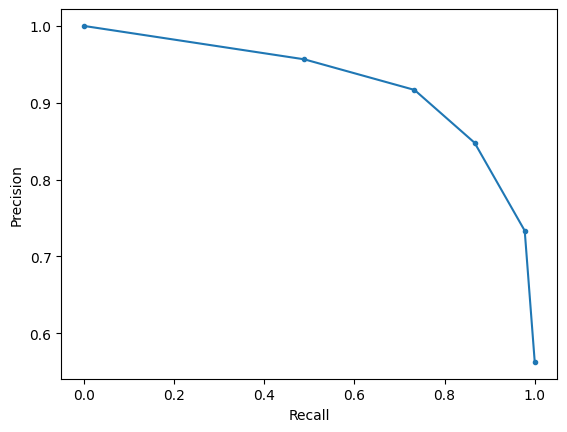


Below is the confusion matrix: 


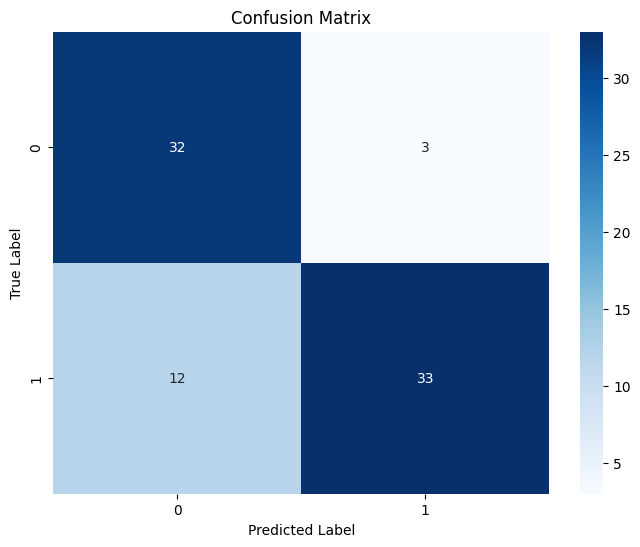

In [87]:
# write your code below to replace the ellipsis "..."
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
probs = estimator_kn.predict_proba(X_test)[:,1]
# calculating F1 score for K-nearest neighbours classifier
score = metrics.f1_score(y_test,predict_kn_hp)
# Report the overall F1 score
print("F1 score for K-nearest neighbours classifier: {0}".format(np.average(score)))

prec, recall, _ = metrics.precision_recall_curve(y_test, probs)
print("precision: {0}".format(metrics.precision_score(y_test, predict_kn_hp)))
print("Recall: {0}".format(metrics.recall_score(y_test, predict_kn_hp)))
print("AUPRC score: {0}".format(metrics.auc(recall,prec)))

# Generate the PR curve
print("Below is the precision recall curve: ")
plt.plot(recall, prec, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()
# generate confusion matrix
conf_matrix = confusion_matrix(y_test, predict_kn_hp)
print("")
print("Below is the confusion matrix: ")
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

---
## Question 2: Regression (10 marks)

In this question you are given a simple dataset which you will perform regression on to predict values. You will build TWO Regression models and then take the best one and perform hyperparameter tuning on it.

## Set up the environment

In [88]:
import numpy as np
from sklearn.model_selection import train_test_split

## Read in the data

You'll need to download the data.csv file from https://ncl.instructure.com/courses/53509/files/7657710?wrap=1 and upload it to your Google Drive. I placed it in a folder called data. Then you need to mount your Google Drive in Colab (cell below).

In [89]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Then read in the data

In [90]:
data = np.loadtxt('/content/drive/MyDrive/data/data.csv', delimiter=',')
print(data)

[[1.00000000e+00 9.00000000e+00 2.57259990e+00 2.49788633e+02]
 [1.00000000e+00 5.00000000e+00 9.21413366e+00 5.04502032e+02]
 [1.00000000e+00 1.70000000e+01 7.12330090e+00 1.33580225e+03]
 ...
 [5.00000000e+00 3.10000000e+01 6.80121067e+00 3.15979690e+03]
 [5.00000000e+00 1.00000000e+01 4.14995662e+00 6.21315789e+02]
 [5.00000000e+00 9.00000000e+00 9.61878173e+00 1.30105857e+03]]


## Q2.1 Split the data into X and y

X is the first three columns

y is the last column

In [91]:
# your answer here
#splitting data into X and y
col_names= [f"Column{i}" for i in range(1,data.shape[1] + 1)]
df = pd.DataFrame(data,columns=col_names)
#removing column4 from X
X= df.drop("Column4",axis=1)
y=df["Column4"]
print("X ", X)
print("y",y)

X       Column1  Column2   Column3
0        1.0      9.0  2.572600
1        1.0      5.0  9.214134
2        1.0     17.0  7.123301
3        1.0     31.0  4.103547
4        1.0     25.0  7.351492
..       ...      ...       ...
995      5.0     26.0  9.124585
996      5.0     28.0  2.375734
997      5.0     31.0  6.801211
998      5.0     10.0  4.149957
999      5.0      9.0  9.618782

[1000 rows x 3 columns]
y 0       249.788633
1       504.502032
2      1335.802246
3      1402.735247
4      2021.981205
          ...     
995    3559.764267
996    1000.884554
997    3159.796899
998     621.315789
999    1301.058568
Name: Column4, Length: 1000, dtype: float64


## Q2.2 Create the Train and Test datasets

20% of the data is kept back for testing

In [92]:
# your answer here
#Splitting data into test and train with 20% data for test
print("x size ", len(X))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)
print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

x size  1000
Training set size: 800
Test set size: 200


## Q2.3 Use TWO Regression approaches on the dataset

In each case report the R^2 value against the test data.

Q2.3.1 Regression approach 1

In [93]:
# your answer here
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
#linear Regression
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)
y_pred = linear_reg.predict(X_test)

In [94]:
#printing the R^2 value
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

R-squared: 0.8621596230850633


Q2.3.2 Regression approach 2

In [95]:
# your answer here
from sklearn.ensemble import RandomForestRegressor
#random forest Regression
random_forest_reg =  RandomForestRegressor()
random_forest_reg.fit(X_train, y_train)
pred_rf = random_forest_reg.predict(X_test)
#printing the R^2 value
r2_rf = r2_score(y_test, pred_rf)
print("R-squared:", r2_rf)

R-squared: 0.9930207652093251


## Q2.4 Optimise the hyperparameters

Take your best Regression approach from above and identify the best hyperparameters. Note as some Regression approaches have many hyperparameters you may limit yourself here to just THREE.

Q2.4.1 Search for the best hyperparameters

In [96]:
# your answer here
#random forest Regression with hyper parameter tuning
param_grid_rf = dict(max_depth=[5,10,12],n_estimators = [20, 50, 100,200], min_samples_split= [2, 5, 10])

grid_search_rf = GridSearchCV(random_forest_reg,param_grid=param_grid_rf,cv=5,scoring="r2",verbose=0,n_jobs=4)
grid_search_rf.fit(X_train,y_train)
# Printing the values of the parameters chosen by grid search
estimator_rf = grid_search_rf.best_estimator_


Q2.4.2 Output the best hyperparameters found

In [97]:
# your answer here
#printing the best parameters selected by regression model
grid_search_rf.best_params_

{'max_depth': 12, 'min_samples_split': 2, 'n_estimators': 50}

Q2.4.3 Show the results for the best model

In [98]:
# your answer here
#printing the R^2 value
y_pred_rf_hp = estimator_rf.predict(X_test)
r2_rf_hp = r2_score(y_test, y_pred_rf_hp)
print("R-squared:", r2_rf_hp)

R-squared: 0.9936443760751065


---
## Question 3: Deep Learning (10 marks)

Q3.1 For MNIST dataset, implement a deep learning model with 3 hidden layers with layer size: 128, 256, 50.


In [99]:
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout
from keras.datasets import mnist
import keras.utils as utils

batch_size = 128
nb_classes = 10
im_dim = 784 # the total pixel number
nb_epoch = 2

In [100]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(60000, im_dim)
X_test = X_test.reshape(10000, im_dim)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255
Y_train = utils.to_categorical(y_train, nb_classes)
Y_test = utils.to_categorical(y_test, nb_classes)

11490434/11490434 [==============================] - 0s 0us/step


In [101]:
# Write down your code about MLP model for question Q3.1 here
# you should call your model 'model'
# deep learning model with 3 hidden layers with layer size: 128, 256, 50
model = Sequential()
model.add(Dense(128, input_dim=im_dim, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(50, activation='relu'))
model.add(Dense(nb_classes))
model.add(Activation('softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


Add code to output your network structure

In [102]:
# your code here
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 128)               100480    
                                                                 
 dense_3 (Dense)             (None, 256)               33024     
                                                                 
 dense_4 (Dense)             (None, 50)                12850     
                                                                 
 dense_5 (Dense)             (None, 10)                510       
                                                                 
 activation (Activation)     (None, 10)                0         
                                                                 
Total params: 146864 (573.69 KB)
Trainable params: 146864 (573.69 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Train the model for just two epochs to show it works. All code provided - just run.

In [103]:
# Train
history = model.fit(X_train, Y_train, epochs=nb_epoch,
                    validation_split = 0.2,
                    batch_size=batch_size, verbose=1)

# Evaluate
evaluation = model.evaluate(X_test, Y_test, verbose=1)
print('Summary: Loss over the test dataset: %.2f, Accuracy: %.2f' % (evaluation[0], evaluation[1]))

Epoch 1/2
375/375 [==============================] - 3s 7ms/step - loss: 0.3426 - accuracy: 0.9012 - val_loss: 0.1612 - val_accuracy: 0.9543
Epoch 2/2
313/313 [==============================] - 1s 2ms/step - loss: 0.1083 - accuracy: 0.9643
Summary: Loss over the test dataset: 0.11, Accuracy: 0.96


Q 3.2 For MNIST dataset, implement a CNN model with only one 2D CNN layer as the hidden layer.

In [104]:
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras import backend as K

batch_size = 128
num_classes = 10
epochs = 2

# the data, shuffled and split between train and test sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# input image dimensions
img_rows, img_cols = 28, 28
x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


In [105]:
# Write down your code about the CNN model of Q3.2 here
# you should call your model 'model'

model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=(img_rows, img_cols, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss=keras.losses.categorical_crossentropy, optimizer='adam', metrics=['accuracy'])


Add code to output your network structure

In [106]:
# your code here
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 32)          0         
 g2D)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 6, 6, 32)          0         
                                                                 
 flatten (Flatten)           (None, 1152)              0         
                                                                 
 dense_6 (Dense)             (None, 128)              

We just train for two epochs to demonstrate that the network does work. Just run it.

In [107]:
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs,
              verbose=1, shuffle=True,
              validation_split = 0.2)
score = model.evaluate(x_test, y_test, verbose=0)
print('Summary: Loss over the test dataset: %.2f, Accuracy: %.2f' % (score[0], score[1]))

Epoch 1/2
375/375 [==============================] - 20s 50ms/step - loss: 0.5475 - accuracy: 0.8308 - val_loss: 0.1503 - val_accuracy: 0.9584
Epoch 2/2
375/375 [==============================] - 20s 53ms/step - loss: 0.2149 - accuracy: 0.9356 - val_loss: 0.0973 - val_accuracy: 0.9727
Summary: Loss over the test dataset: 0.09, Accuracy: 0.97


---
---
---
#Mini-projects: Introduction

The remainder of this document defines four project-style questions which go more deeply into one of the areas from the module. You should pick **ONE** of these project-stye questions to answer.

The learning objectives of this assignment are:
1. To learn about the design of machine learning analysis pipelines
2. To understand how to select appropriate methods given the dataset type
3. To learn how to conduct machine learning experimentation in a rigorous and effective manner
4. To critically evaluate the performance of the designed machine learning pipelines
5. To learn and practice the skills of reporting machine learning experiments

For this coursework you will be provided with a choice of four different datasets of different nature
1. A tabular dataset (defined as a classification problem)
2. An image dataset
3. A text dataset
4. A time series dataset

Your job is easy to state: You should pick ONE out of these four options and design a range of machine learning pipelines appropriate to the nature of each of the selected datasets. Overall, we expect that you will perform a thorough investigation involving (whenever relevant) all parts of a machine learning pipeline (exploration, preprocessing, model training, model interpretation and evaluation), evaluating a range of options for all parts of the pipeline and with proper hyperparameter tuning.

You will have to write a short report (as part of this notebook) that presents the experiments you did, their justification, a detailed description of the performance of your designed pipelines using the most appropriate presentation tools (e.g., tables of results, plots). We expect that you should be able to present your work at a level of detail that would enable a fellow student to reproduce your steps.

## Deliverables
An inline report and code blocks addressing the marking scheme below. The report should have 1000 to 2000 words. The word count excludes references, tables, figures and section headers, and has a 10% leeway.

## Marking scheme

- Writing Style, references, figures, etc. 7 marks
- Dataset exploration 7 marks
- Methods 21 marks
- Results of analysis 21 marks
- Discussion 14 marks

---
---
## Project 1: Tabular dataset (70 marks)

The dataset, called FARS, is a collection of statistics of US road traffic accidents. The class label is about the severity of the accident. It has 20 features and over 100K examples. The dataset is available in Canvas as a CSV file, in which the last column contains the class labels: https://ncl.instructure.com/courses/53509/files/7652449/download?download_frd=1

Experiments on the tabular dataset will be relatively fast compared to the other three options. To compensate, we expect that you evaluate a very broad range of options for the design of your machine learning pipelines, including (but not limited to) data normalisation, feature/instance selection, class imbalance correction, several (appropriate) machine learning models, hyperparameter tuning and cross-validation evaluation.

## Your answer below

---
---
## Project 2: Image dataset (70 marks)

The FMNISTMash dataset is an extension to the FMNIST dataset. In each 3-colour channel image there is one FMNIST image in each channel (see example below). The idea is to predict the number of unique classes in the three channels (0 - all images are of the same class, 1 - two different classes, 2 - three different classes). So for the example image there is a top and two jackets so lable is 1. Please download the data from:

|Data| URL|
|---|------|
|Train X | http://homepages.cs.ncl.ac.uk/stephen.mcgough/data/FMNISTMash/train_x.npy |
| Train y | http://homepages.cs.ncl.ac.uk/stephen.mcgough/data/FMNISTMash/train_y.npy |
| Validate X | http://homepages.cs.ncl.ac.uk/stephen.mcgough/data/FMNISTMash/valid_x.npy |
| Validate y | http://homepages.cs.ncl.ac.uk/stephen.mcgough/data/FMNISTMash/valid_y.npy |
| Test X | http://homepages.cs.ncl.ac.uk/stephen.mcgough/data/FMNISTMash/test_x.npy |
| Test y | http://homepages.cs.ncl.ac.uk/stephen.mcgough/data/FMNISTMash/test_y.npy |

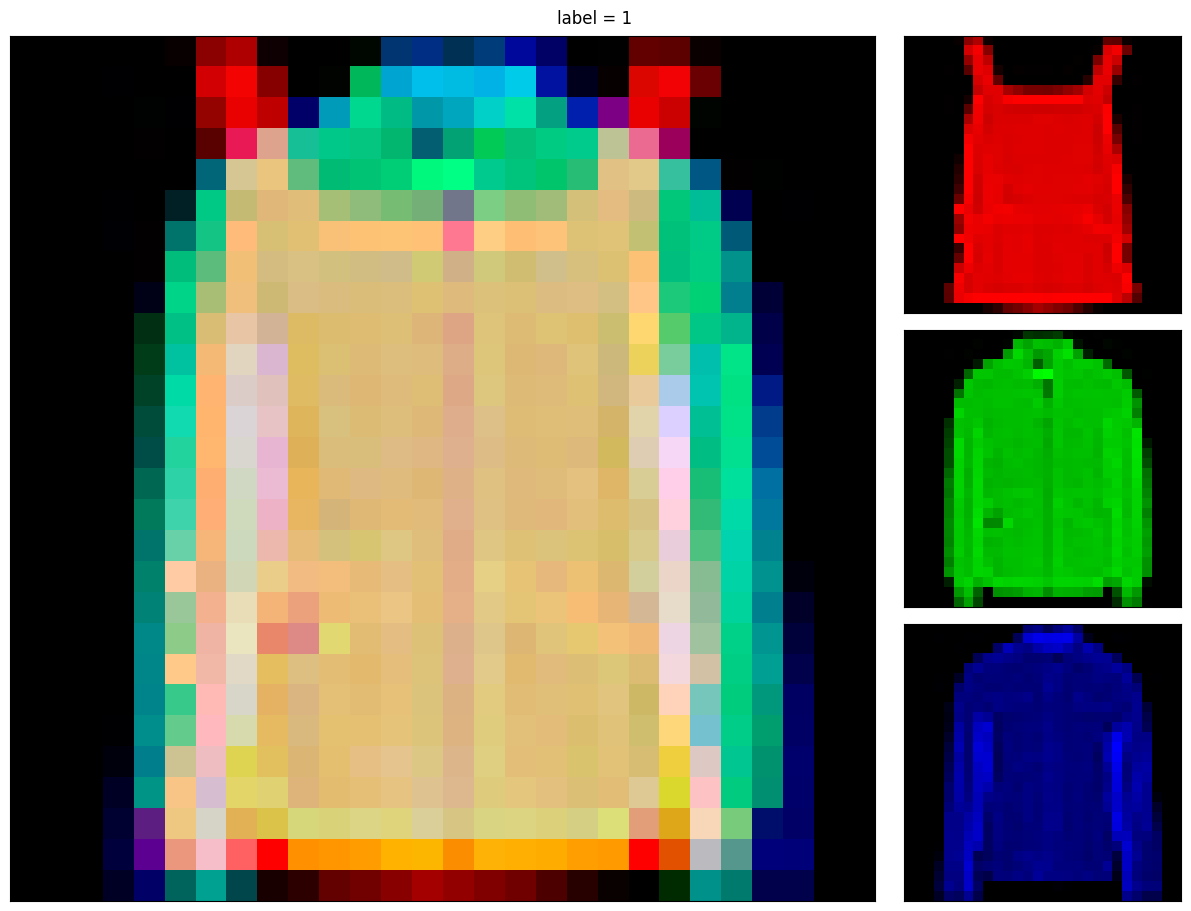
Figure 1: Example image from the FMNISTMash dataset, class label is 1

Your task is to produce TWO models for predicting the class of the image. Note: you can do ONE model which splits the image into its separate colour channels and performs a classification on them separately, but the other MUST work on all three chanels together.

Some hints:
- The code below shows you how to load and view the data.
- To speed up your work here are some hints (assuming you’re using Colab):
 - Make sure you set the Runtime type to either GPU or TPU.
 - Copy the data to your Google drive so you don’t have to keep uploading it. Full information on how to do this can be found at: https://colab.research.google.com/notebooks/io.ipynb
 - As the dataset is large you might want to do some of your initial testing on a subset of the data.

To load the data, we reccomend storing it in your Google Drive, this means you won't need to load it into the local colab storage every time you open the notebook.

The following import will allow your notebook to connect to Google Drive. When you run this cell a seperate window will pop up asking you to grant Drive access to colab. Grant it access to the account which contains FMNISTMash

## Load the data

The dataset is stored as six Numpy files, so to load them we will need to import Numpy. Before loading each file into its own vaiable.

**Note: you'll need to change the location of the file to wherever you stroed your files.**

In [ ]:
import numpy as np

train_x = np.load('/content/drive/MyDrive/data/FMNISTMash/train_x.npy', allow_pickle = True)
train_y = np.load('/content/drive/MyDrive/data/FMNISTMash/train_y.npy', allow_pickle = True)
valid_x = np.load('/content/drive/MyDrive/data/FMNISTMash/valid_x.npy', allow_pickle = True)
valid_y = np.load('/content/drive/MyDrive/data/FMNISTMash/valid_y.npy', allow_pickle = True)
test_x = np.load('/content/drive/MyDrive/data/FMNISTMash/test_x.npy', allow_pickle = True)
test_y = np.load('/content/drive/MyDrive/data/FMNISTMash/test_y.npy', allow_pickle = True)

## Check the shape of the data
Make sure the data is loaded and in the shape that you expect, FMNISTMash has 50,000 training images, 10,000 validation images, and 10,000 testing images.

In [ ]:
print(f'train_x shape: {train_x.shape}')
print(f'train_y shape: {train_y.shape}')
print(f'valid_x shape: {valid_x.shape}')
print(f'valid_y shape: {valid_y.shape}')
print(f'test_x shape: {test_x.shape}')
print(f'test_y shape: {test_y.shape}')

## Displaying the Images

### Displaying the single image

To display the images we are going to be using MatPlotLib, so we need to import that, standard practice is to import it as plt

In [ ]:
import matplotlib.pyplot as plt

The following two functions aren't necessary, they simply remove the axis ticks and numbers from the rendered image and perform some normalisation to the image.

In [ ]:
def disable_ax_ticks(ax):
    ax.set_xticks([])
    ax.set_xticks([], minor=True)
    ax.set_yticks([])
    ax.set_yticks([], minor=True)

In [ ]:
def image_normalisation(arr):
    return (arr - arr.min())/(arr.max()-arr.min())

We construct the figure using plt, pyplot expects the colour channel to be last, the data is saved in a channels_first format so needs to be converted which is what we used np.move_axis for.

In [ ]:
def display_image(x, y):
    fig = plt.figure()
    main_ax = fig.add_subplot()
    fig.suptitle('label = '+ str(y))
    main_ax.imshow(image_normalisation(np.moveaxis(x, 0, -1)))
    disable_ax_ticks(main_ax)
    plt.show()

## Pick a random example and plot it

We want to plot a random image, so we import random and pick a random index using the number of images in train_x as a limit.

In [ ]:
import random

ri = random.randrange(train_x.shape[0])

We now render the image, the label indicates how many different FMNIST classes appear in the image.

- 0 = All images are the same class
- 1 = Two images share the same class
- 2 = All images are from different classes

In [ ]:
display_image(train_x[ri], train_y[ri])

## Splitting the Image

This next section is just to make the dataset easier to understand. We will display the image, and then the three images that make it up seperately.

In [ ]:
def show_mnist_examples(x, y):
  fig = plt.figure(constrained_layout=True,figsize=(12,9), dpi=100)
  gs = fig.add_gridspec(3,4)
  main_ax = fig.add_subplot(gs[:3,:3])
  fig.suptitle('label = '+ str(y))
  main_ax.imshow(image_normalisation(np.moveaxis(x, 0, -1)))
  disable_ax_ticks(main_ax)

  for j in range(3):
      c_ax = fig.add_subplot(gs[j,-1])
      subimage = x.copy()
      subimage[:j] = 0
      subimage[j+1:] = 0
      subimage[j] = subimage[j]-subimage[j].min()
      c_ax.imshow(image_normalisation(np.moveaxis(subimage, 0, -1)))
      disable_ax_ticks(c_ax)
  plt.show()

Hopefully, you will see the same image rendered early along with the images in the respective colour channels, and you should be able to see which ones share a class from FMNIST and which ones differ. Careful though, as some classes are similar to others.

In [ ]:
show_mnist_examples(train_x[ri], train_y[ri])

## Your answer below

---
---
## Project 3: Text dataset (70 marks)

Dataset: sentiment analysis dataset (on canvas: (https://ncl.instructure.com/courses/53509/files/7666186?wrap=1), (https://ncl.instructure.com/courses/53509/files/7666193?wrap=1), (https://ncl.instructure.com/courses/53509/files/7666197?wrap=1)).
Each sample in the dataset represents a tweet. Each tweet has a sentiment label (Positive, Negative, Neutral).

**Task Description:** Apply **a combination of** different approaches including pre-processing techniques, shallow and deep classifiers, ensembled approaches, machine learning approaches beyond supervised learning if applicable, data augmentation if applicable to predict the sentiment of the test set. Try your best to improve the prediction results.

Primary **Evaluation metrics: F-1 measure**. Though you should also use others.

## Your answer below


#TWEET SENTIMENT ANALYSIS

**Introduction**

---

The aim of this project is to train a machine learning model to derive the sentiment of tweets. I have trained my model by applying a combination of different approaches explained in the inline comments before code blocks in the notebook.

Additionally,there are 3 datasets: dev, train and test.
The Machine learning model is trained on train dataset, dev is used for validation and debugging errors (so that computation time is low) and test are used to test the results of the output.

**First step is to install and import all required libraries and load the datasets:**

In [2]:
#Install required libraries
! pip install nltk scikit-learn pandas tensorflow vaderSentiment

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.6 MB/s eta 0:00:00


In [6]:
#Import required modules
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelBinarizer
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.utils import class_weight
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from imblearn.over_sampling import SMOTE

In [27]:
#Load the data sets
tweets_dev = pd.read_csv('Tweets_dev (1).csv')
tweets_test = pd.read_csv('Tweets_test (1) (2).csv',encoding ='latin')
tweets_train = pd.read_csv('Tweets_train (2).csv')

#used for preprocessing to remove and tokenize stop words
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

**Dataset Exploration**

---
Before beginning the tweet sentiment analysis, we need to explore the data to understand its characteristics and gain insights.


Sample tweets:


,tweet_id,text,airline_sentiment
0,569179849518161920,@united you're good. Thank you!,positive
1,569835751275433984,"@AmericanAir way to ruin a vacation, my brothe...",negative
2,568588936852799488,@JetBlue yes thankfully! Catering just got her...,positive
3,569525116725567491,@USAirways The automated message isn't helpful...,negative
4,568807823187976193,@JetBlue I'm #MakingLoveOutofNothingAtAll on m...,positive



Overview of the datasets on train dataset:
Train: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11858 entries, 0 to 11857
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   tweet_id           11858 non-null  int64 
 1   text               11858 non-null  object
 2   airline_sentiment  11858 non-null  object
dtypes: int64(1), object(2)
memory usage: 278.0+ KB
None
Test: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1464 entries, 0 to 1463
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   tweet_id           1464 non-null   int64 
 1   text               1464 non-null   object
 2   airline_sentiment  1464 non-null   object
dtypes: int64(1), object(2)
memory usage: 34.4+ KB
None
Dev: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1318 entries, 0 to 1317
Data columns (total 3 columns):
 #   Column             Non-Null

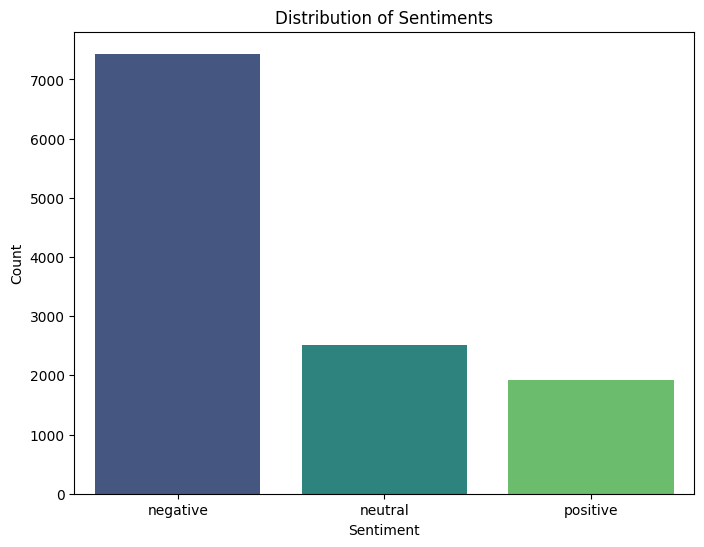

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns

# Display the first few rows of the dataset
print("Sample tweets:")
display(tweets_train.head())

# Overview of the dataset
print("\nOverview of the datasets on train dataset:")
print("Train: ")
print(tweets_train.info())
print("Test: ")
print(tweets_test.info())
print("Dev: ")
print(tweets_dev.info())
# # Distribution of sentiments
sentiment_distribution = tweets_train['airline_sentiment'].value_counts()
print("\n",sentiment_distribution.describe)
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_distribution.index, y=sentiment_distribution.values, palette="viridis")
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In the above graph we can see the negative tweets are comparitely way higher than nuetral and positive with 7434 records.
Below I can see in the graph that majority of the negative tweets have 125 characters in a tweet.

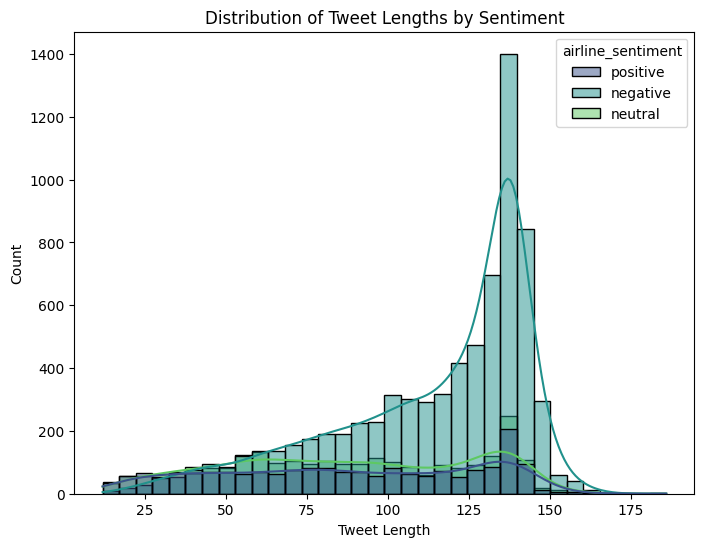

In [92]:
# Tweet length analysis
tweets_train['tweet_length'] = tweets_train['text'].apply(len)
plt.figure(figsize=(8, 6))
sns.histplot(tweets_train, x='tweet_length', hue='airline_sentiment', kde=True, palette="viridis")
plt.title('Distribution of Tweet Lengths by Sentiment')
plt.xlabel('Tweet Length')
plt.ylabel('Count')
plt.show()

Below we can see the mentions are not useful for our analysis and only few hashtags are useful.

In [100]:
# Extract hashtags and mentions and count occurrences
hashtags_count = tweets_train['text'].str.extractall(r'#(\w+)').stack().value_counts()
mentions_count = tweets_train['text'].str.extractall(r'@(\w+)').stack().value_counts()

# Display the count of hashtags and mentions
print("Top 10 Hashtags:")
display(hashtags_count.head(10))

print("\nTop 10 Mentions:")
display(mentions_count.head(10))

Top 10 Hashtags:


DestinationDragons    62
fail                  41
UnitedAirlines        29
jetblue               29
customerservice       25
usairwaysfail         24
AmericanAirlines      20
badservice            17
avgeek                16
disappointed          15
dtype: int64


Top 10 Mentions:


united           3046
AmericanAir      2365
USAirways        2329
SouthwestAir     1959
JetBlue          1797
VirginAmerica     411
United            109
usairways          68
Delta              41
jetblue            36
dtype: int64

**Preprocessing**


---


Data preprocessing is done by removing anything the machine learning model will not require to learn. This saves confusion and computing time.

List of things being changed:

1. Tags (eg. @united), any URLs mentioned in the tweets, special characters, punctuations and numbers using regular expression(re).
2. Converting all data to lower case to maintain consistency of the data
3. Insignificant words - stop words which are not contributing to the sentiment of the tweets using The Natural Language Toolkit (nltk) library of python.


In [29]:
def preprocess_tweet(tweet):
    # Remove Twitter handles
    tweet = re.sub(r'@\w+', '', tweet)

    # Remove URLs
    tweet = re.sub(r'http\S+', '', tweet)

    # Remove special characters and punctuation
    tweet = re.sub(r'[^a-zA-Z0-9\s]', '', tweet)

    # Remove numbers
    tweet = re.sub(r'\d+', '', tweet)

    # Convert to lowercase
    tweet = tweet.lower()

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(tweet)
    tweet = ' '.join([word for word in tokens if word not in stop_words])

    return tweet

tweets_train['preprocessed_text'] = tweets_train['text'].apply(preprocess_tweet)
tweets_test['preprocessed_text'] = tweets_test['text'].apply(preprocess_tweet)
tweets_dev['preprocessed_text'] = tweets_dev['text'].apply(preprocess_tweet)



**Feature Extraction**

---


1. The Term  Frequency Inverse Document Frequency (TF-IDF) Vectorizer is utilized to convert text (tweets) into TF-IDF features, representing all words as integers based on their importance in the file. This text data is assigned to X.
2. Simultaneously, I have mapped the string values (airline sentiment - negative, neutral, positive) into integers where 0 stands for neutral, 1 for negative and 2 for positive.

In [30]:
#Transforming text to integer matrix and assinging to X for train data
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(tweets_train['preprocessed_text'])

# Class labels are strings - neutral, positive, negative - and have to be converted to integers and assinging to y
# Define a custom label mapping
label_mapping = {"neutral": 0, "negative": 1, "positive": 2}

y = tweets_train['airline_sentiment']

y_train = [label_mapping[label] for label in y]

#For test data
X_test = vectorizer.transform(tweets_test['preprocessed_text'])
y_test = tweets_test['airline_sentiment']
y_test = [label_mapping[label] for label in y_test]

#For dev data
X_dev = vectorizer.transform(tweets_dev['preprocessed_text'])
y_dev = tweets_dev['airline_sentiment']
y_dev = [label_mapping[label] for label in y_dev]


In the rest of the notebook, I have tried various classification techniques suitable for text data for sentiment analysis, and selected the ones which give the best results.

**Shallow Classification Techniques**

---

I have implemented **Random Forest, Support Vector Classifier (SVC), and Multinomial Naive Bayes classification** supervised learning methods in the code below, to
**compare the precision, recall, f1-score and overall accuracy of each.**
On investigating the results, I observed that the results for SVC seems the best among the three and decided to select that as one of the classifier I'll use.
The reason for  that is in SVC, all the scores are higher, as seen below after running the cells.

I tried **Random Forest Classifier** as it is an ensemble learning method, getting best results of multiple decision trees and the ability of random forest to create a non-linear relationship with text. [1]


In [11]:
#Random Forest Classifier
rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train, y_train)

#Predicting values test
rf_preds = rf_classifier.predict(X_test)
print("Classification Report - Test Data (Random Forest Classifier):")
print(classification_report(y_test, rf_preds))

#Predicting values dev
rf_preds_dev = rf_classifier.predict(X_dev)
print("Classification Report - Dev Data (Random Forest Classifier):")
print(classification_report(y_dev, rf_preds_dev))



Classification Report - Test Data (Random Forest Classifier):
              precision    recall  f1-score   support

           0       0.57      0.52      0.54       310
           1       0.84      0.87      0.85       918
           2       0.66      0.67      0.66       236

    accuracy                           0.76      1464
   macro avg       0.69      0.68      0.69      1464
weighted avg       0.75      0.76      0.76      1464

Classification Report - Dev Data (Random Forest Classifier):
              precision    recall  f1-score   support

           0       0.56      0.50      0.53       279
           1       0.82      0.86      0.84       826
           2       0.66      0.63      0.64       213

    accuracy                           0.75      1318
   macro avg       0.68      0.66      0.67      1318
weighted avg       0.74      0.75      0.74      1318



**Support Vector Classifier (SVC)** performs classification by finding the hyper-plane that differentiates the classes we plotted in n-dimensional space. This is also useful as we have a non linear relationship between text and label. [2]


In [10]:
#SVM Classifier without hyperparameters
svc_classifier = SVC(kernel='linear', probability=True, random_state=1)
svc_classifier.fit(X_train, y_train)

#Predicting values test and dev
svc_preds = svc_classifier.predict(X_test)
svc_preds_dev = svc_classifier.predict(X_dev)

# Printing result
print("Classification Report - Test Data (Support Vector Classifier): " )
print(classification_report(y_test, svc_preds))
print("Classification Report - Dev Data (Support Vector Classifier): " )
print(classification_report(y_dev, svc_preds_dev))

Classification Report - Test Data (Support Vector Classifier): 
              precision    recall  f1-score   support

           0       0.54      0.63      0.58       310
           1       0.88      0.82      0.85       918
           2       0.68      0.71      0.69       236

    accuracy                           0.76      1464
   macro avg       0.70      0.72      0.71      1464
weighted avg       0.78      0.76      0.77      1464

Classification Report - Dev Data (Support Vector Classifier): 
              precision    recall  f1-score   support

           0       0.55      0.62      0.58       279
           1       0.87      0.81      0.84       826
           2       0.68      0.73      0.70       213

    accuracy                           0.76      1318
   macro avg       0.70      0.72      0.71      1318
weighted avg       0.77      0.76      0.76      1318



As we have 3 label values, I have tuned the kernel parameter to be rbf using gridSearchCV.
After tuning the hyperparameters for SVC, I observed the results have increased, and F1 score, precision, recall score all are better balanced for positive, nuetral and negative sentiment. The metrics for SVC are better than N-Bayes (In the code blocks after SVC) and Random forest classifiers.

Due to these observations I have **selected** **SVC** as one of my training models.



In [31]:
#SVC with hyperparameter tuning
svc_classifier = SVC(kernel='linear', probability=True, random_state=2)
param_grid = {
    'C': [1, 10],
    'kernel': ['rbf'],
    'class_weight': ['balanced']
}
grid_search_svc = GridSearchCV(svc_classifier, param_grid, cv=3, scoring='f1_weighted', n_jobs=-1)
# Fit the model for SVC
grid_search_svc.fit(X_train, y_train)

# Get the best parameters
best_params_svc = grid_search_svc.best_params_
print("Best Hyperparameters for SVC:", best_params_svc)
print("")

# Use the best estimator for predictions
best_svc_classifier = grid_search_svc.best_estimator_

#Predict for test and dev
svc_preds_test = best_svc_classifier.predict(X_test)
svc_preds_dev = best_svc_classifier.predict(X_dev)

# Evaluate the SVC model
print("Classification Report - Test Data (svc):")
print(classification_report(y_test, svc_preds_test))

print("\nClassification Report - Dev Data (svc):")
print(classification_report(y_dev, svc_preds_dev))

Best Hyperparameters for SVC: {'C': 1, 'class_weight': 'balanced', 'kernel': 'rbf'}

Classification Report - Test Data (svc):
              precision    recall  f1-score   support

           0       0.60      0.65      0.62       310
           1       0.88      0.87      0.88       918
           2       0.75      0.71      0.73       236

    accuracy                           0.80      1464
   macro avg       0.74      0.74      0.74      1464
weighted avg       0.80      0.80      0.80      1464


Classification Report - Dev Data (svc):
              precision    recall  f1-score   support

           0       0.57      0.62      0.59       279
           1       0.85      0.85      0.85       826
           2       0.76      0.69      0.72       213

    accuracy                           0.77      1318
   macro avg       0.73      0.72      0.72      1318
weighted avg       0.78      0.77      0.77      1318



I decided to try **Multinomial N-Bayes** model as it  computes  the probabilies  of  each of the  text  fitting  into  separate classes. [3]

In [10]:
#N Bayes Classifier
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

#Predicting values test
nb_preds = nb_classifier.predict(X_test)
print("Classification Report - Test Data (N Bayes Classifier)")
print(classification_report(y_test, nb_preds))

#Predicting values prod
nb_preds_dev = nb_classifier.predict(X_dev)
print("N Bayes Classifier results for DEV")
print(classification_report(y_dev, nb_preds_dev))

Classification Report - Test Data (N Bayes Classifier)
              precision    recall  f1-score   support

           0       0.81      0.15      0.26       310
           1       0.68      0.99      0.81       918
           2       0.87      0.23      0.37       236

    accuracy                           0.69      1464
   macro avg       0.79      0.46      0.48      1464
weighted avg       0.74      0.69      0.62      1464

N Bayes Classifier results for DEV
              precision    recall  f1-score   support

           0       0.74      0.11      0.19       279
           1       0.67      1.00      0.80       826
           2       0.87      0.19      0.31       213

    accuracy                           0.68      1318
   macro avg       0.76      0.43      0.43      1318
weighted avg       0.72      0.68      0.59      1318



Tuning hyperparameters to check the optimal results of n-bayes and compare with SVC

In [11]:
#Multinomial Naive Bayes with hyperparameter tuning
nb_classifier = MultinomialNB()
param_grid_nb = {
    'alpha': [0.1, 0.5, 1.0, 1.5, 2.0],  # Smoothing parameter
}
grid_search_nb = GridSearchCV(nb_classifier, param_grid_nb, cv=5, scoring='f1_weighted', n_jobs=-1)

# Fit the model for Multinomial Naive Bayes
grid_search_nb.fit(X_train, y_train)

# Get the best parameters
best_params_nb = grid_search_nb.best_params_
print("Best Hyperparameters for Multinomial Naive Bayes:", best_params_nb)

# Use the best estimator for predictions
best_nb_classifier = grid_search_nb.best_estimator_

#Predict values for test and dev
nb_preds_test = best_nb_classifier.predict(X_test)
nb_preds_dev = best_nb_classifier.predict(X_dev)

# Evaluate the Multinomial Naive Bayes model
print("Classification Report - Test Data (Multinomial Naive Bayes):")
print(classification_report(y_test, nb_preds_test))


print("\nClassification Report - Dev Data (Multinomial Naive Bayes):")
print(classification_report(y_dev, nb_preds_dev))

Best Hyperparameters for Multinomial Naive Bayes: {'alpha': 0.1}
Classification Report - Test Data (Multinomial Naive Bayes):
              precision    recall  f1-score   support

           0       0.69      0.40      0.51       310
           1       0.77      0.96      0.85       918
           2       0.80      0.48      0.60       236

    accuracy                           0.76      1464
   macro avg       0.75      0.61      0.65      1464
weighted avg       0.76      0.76      0.74      1464


Classification Report - Dev Data (Multinomial Naive Bayes):
              precision    recall  f1-score   support

           0       0.69      0.34      0.45       279
           1       0.75      0.96      0.84       826
           2       0.79      0.44      0.56       213

    accuracy                           0.74      1318
   macro avg       0.74      0.58      0.62      1318
weighted avg       0.74      0.74      0.71      1318



**Deep Classification Technique**

---


Convolutional Neural Network(CNN) is a deep classification technique.
The CNN model is built using Keras, running on top of TensorFlow. CNN focuses on text patterns irrespective of order of words, and suits the tweet text style.  

In [12]:
# one hot encoding for deep classifier : CNN

# One-hot encode y_train
label_binarizer = LabelBinarizer()
y_train_onehot = label_binarizer.fit_transform(y_train)

# One-hot encode y_test
y_test_onehot = label_binarizer.transform(y_test)

# One-hot encode y_dev
y_dev_onehot = label_binarizer.transform(y_dev)


In [13]:
#CNN Classifier
# Setting max length of single tweet, assuming after removing so many unnecessary data
#and considering tweet lengths in data exploration at the start for tweet should be 100
# also this balances the data as the tweets over 100 characters have only negative sentiment
max_length = 100

# Tokenize the text data
tokenizer = Tokenizer()
tokenizer.fit_on_texts(pd.concat([tweets_train['preprocessed_text'], tweets_test['preprocessed_text'], tweets_dev['preprocessed_text']]))

# Convert text data to sequences
X_train_sequences = tokenizer.texts_to_sequences(tweets_train['preprocessed_text'])
X_dev_sequences = tokenizer.texts_to_sequences(tweets_dev['preprocessed_text'])
X_test_sequences = tokenizer.texts_to_sequences(tweets_test['preprocessed_text'])

# Pad sequences to ensure uniform length
X_train_padded = pad_sequences(X_train_sequences, maxlen=max_length)  # Set max_length as per your requirement
X_dev_padded = pad_sequences(X_dev_sequences, maxlen=max_length)
X_test_padded = pad_sequences(X_test_sequences, maxlen=max_length)

# Define CNN model
model = Sequential()
model.add(Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=100, input_length=max_length, trainable=False))
model.add(Conv1D(128, 5, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(len(label_mapping), activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])

# Train the model
model.fit(X_train_padded, y_train_onehot, epochs=5, batch_size=32, validation_data=(X_dev_padded, y_dev_onehot))

# Evaluate on test set
accuracy = model.evaluate(X_test_padded, y_test_onehot, verbose=0)[1]
print(f"Accuracy on Test Set: {accuracy:.2f}")


Epoch 1/5
371/371 [==============================] - 13s 31ms/step - loss: 0.8504 - accuracy: 0.6386 - val_loss: 0.7775 - val_accuracy: 0.6965
Epoch 2/5
371/371 [==============================] - 10s 27ms/step - loss: 0.7211 - accuracy: 0.7040 - val_loss: 0.6878 - val_accuracy: 0.7155
Epoch 3/5
371/371 [==============================] - 10s 28ms/step - loss: 0.6091 - accuracy: 0.7501 - val_loss: 0.6555 - val_accuracy: 0.7261
Epoch 4/5
371/371 [==============================] - 11s 30ms/step - loss: 0.4878 - accuracy: 0.8086 - val_loss: 0.6670 - val_accuracy: 0.7375
Epoch 5/5
371/371 [==============================] - 11s 30ms/step - loss: 0.3692 - accuracy: 0.8622 - val_loss: 0.7034 - val_accuracy: 0.7284
Accuracy on Test Set: 0.71


In [14]:
#Deriving classification report CNN

# Make predictions on the test set
y_pred_test = model.predict(X_test_padded)
y_pred_test_classes = np.argmax(y_pred_test, axis=1)

# Convert one-hot encoded y_test_onehot back to class labels
y_test_classes = np.argmax(y_test_onehot, axis=1)

# Calculate and print the classification report
print("\nClassification Report on Test Set (CNN):")
print(classification_report(y_test_classes, y_pred_test_classes))

46/46 [==============================] - 1s 11ms/step

Classification Report on Test Set (CNN):
              precision    recall  f1-score   support

           0       0.52      0.52      0.52       310
           1       0.82      0.82      0.82       918
           2       0.57      0.56      0.57       236

    accuracy                           0.71      1464
   macro avg       0.63      0.63      0.63      1464
weighted avg       0.71      0.71      0.71      1464



After reviewing results for CNN, the metrics look sparse with lower scores. The distribution of scores among precision, recall and f1 is imbalanced and hence will not be selecting this method.

**Logistic Regression:**

---

Unlike the name, it is actually a very nice model for classification. This works on total number of possiblities to classify the labels. It allows analyzing multiple explanatory variables simultaneously reducing the effect of confounding factors. [4]

In [32]:
# Create and train Logistic Regression model
logreg_model = LogisticRegression(max_iter=1000, random_state=5)
logreg_model.fit(X_train, y_train)

# Make predictions
y_pred_logreg = logreg_model.predict(X_test)
y_pred_dev_logreg = logreg_model.predict(X_dev)

# Evaluate performance
print("Logistic Regression Performance on Test Set:")
print(classification_report(y_test, y_pred_logreg))


print("\nLogistic Regression Performance on Dev Set:")
print(classification_report(y_dev, y_pred_dev_logreg))



Logistic Regression Performance on Test Set:
              precision    recall  f1-score   support

           0       0.69      0.50      0.58       310
           1       0.82      0.95      0.88       918
           2       0.82      0.60      0.69       236

    accuracy                           0.80      1464
   macro avg       0.78      0.68      0.72      1464
weighted avg       0.79      0.80      0.78      1464


Logistic Regression Performance on Dev Set:
              precision    recall  f1-score   support

           0       0.67      0.45      0.54       279
           1       0.79      0.93      0.86       826
           2       0.81      0.60      0.69       213

    accuracy                           0.78      1318
   macro avg       0.76      0.66      0.70      1318
weighted avg       0.77      0.78      0.76      1318



The results of **logistic regression** are higher but not as balanced as **SVC**, so will be using Logistic Regression ensembled with SVC Classifier.

**Unsupervised Learning Technique:**

---

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon and rule-based sentiment analysis tool that is specifically attuned to sentiments expressed in social media. [5] This is a unsupervised learning method which suits the exact purpose of the project.
This does not directly improve accuracy but makes the data better clustered to improve the quality of training.


In [33]:
# Create a function to get the sentiment scores using VADER
def get_vader_sentiment(text):
    analyzer = SentimentIntensityAnalyzer()
    sentiment_scores = analyzer.polarity_scores(text)
    compound_score = sentiment_scores['compound']

    # Assign labels based on the compound score
    if compound_score >= 0.05:
        return 'positive'
    elif compound_score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# Apply VADER to your datasets
tweets_train['vader_sentiment'] = tweets_train['text'].apply(get_vader_sentiment)
tweets_test['vader_sentiment'] = tweets_test['text'].apply(get_vader_sentiment)
tweets_dev['vader_sentiment'] = tweets_dev['text'].apply(get_vader_sentiment)

# Evaluate the performance
from sklearn.metrics import accuracy_score, classification_report

# Assuming you have the actual sentiment labels in 'airline_sentiment' column
y_train_actual = y_train
y_test_actual = y_test
y_dev_actual = y_dev

# Convert VADER sentiment labels to match your labels
label_mapping_vader = {"positive": 2, "neutral": 0, "negative": 1}

y_train_vader = tweets_train['vader_sentiment'].map(label_mapping_vader)
y_test_vader = tweets_test['vader_sentiment'].map(label_mapping_vader)
y_dev_vader = tweets_dev['vader_sentiment'].map(label_mapping_vader)

# Evaluate accuracy

#Print classification report
print("\nClassification Report on Test Set:")
print(classification_report(y_test_actual, y_test_vader))



Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.39      0.31      0.34       310
           1       0.91      0.45      0.61       918
           2       0.28      0.92      0.44       236

    accuracy                           0.50      1464
   macro avg       0.53      0.56      0.46      1464
weighted avg       0.70      0.50      0.52      1464



**Ensembling the chosen models:**

---
I tried 2 possible combinations to ensemble the models to check which one gives the best result.
1. In the first code block below, my aim was to check the basic accuracy by ensembling the 3 shallow classifiers: Random Forest, SVC  and N-Bayes using voting esemble technique.
2. In the second approach, I ensembled SVC with hyperparameter tuning, logistic regression and VADER (All the chosen models with higher accuracy, better distribution and suitability to dataset).


In [17]:
# smote = SMOTE(random_state=4)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Create individual classifiers
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=3)
svc_classifier = SVC(kernel='linear', probability=True, random_state=4)
nb_classifier = MultinomialNB()

# # Ensemble classifiers using a VotingClassifier
ensemble_classifier = VotingClassifier(
    estimators=[
        ('random_forest', rf_classifier),
        ('svm', grid_search_svc),
        ('naive_bayes', grid_search_nb)
    ],
    voting='soft'
)

# Train the ensemble classifier
ensemble_classifier.fit(X_train, y_train)

# Make predictions
y_pred = ensemble_classifier.predict(X_test)
y_pred_dev = ensemble_classifier.predict(X_dev)
# Evaluate performance
print("Ensemble Classifier Performance test:")
print(classification_report(y_test, y_pred))

print("Ensemble Classifier Performance dev:")
print(classification_report(y_dev, y_pred_dev))


Ensemble Classifier Performance test:
              precision    recall  f1-score   support

           0       0.75      0.46      0.57       310
           1       0.81      0.95      0.88       918
           2       0.75      0.62      0.68       236

    accuracy                           0.80      1464
   macro avg       0.77      0.68      0.71      1464
weighted avg       0.79      0.80      0.78      1464

Ensemble Classifier Performance dev:
              precision    recall  f1-score   support

           0       0.69      0.43      0.53       279
           1       0.80      0.95      0.87       826
           2       0.78      0.62      0.69       213

    accuracy                           0.78      1318
   macro avg       0.76      0.66      0.70      1318
weighted avg       0.77      0.78      0.77      1318



In the above, only shallow classifier ensemble, the results are still not evenly distributed even after aplying SMOTE from imbalanced-learn library. The scores for negative labels is way higher, and for neutral labels is way lower.

In [34]:
from statistics import mode

# Ensemble predictions
def ensemble_predictions(predictions):
    return mode(predictions)

# Get predictions from individual models
svc_preds_test = best_svc_classifier.predict(X_test)
logreg_preds_test = logreg_model.predict(X_test)
vader_preds_test = tweets_test['vader_sentiment'].map(label_mapping_vader)

# Create an ensemble of predictions
ensemble_preds_test = [ensemble_predictions([svc_pred, logreg_pred, vader_pred])
                       for svc_pred, logreg_pred, vader_pred in zip(svc_preds_test, logreg_preds_test, vader_preds_test)]

# Evaluate the performance of the ensemble
print("Ensemble Performance on Test Set:")
print(classification_report(y_test_actual, ensemble_preds_test))


Ensemble Performance on Test Set:
              precision    recall  f1-score   support

           0       0.63      0.64      0.64       310
           1       0.88      0.89      0.89       918
           2       0.76      0.71      0.73       236

    accuracy                           0.81      1464
   macro avg       0.76      0.75      0.75      1464
weighted avg       0.81      0.81      0.81      1464



This approach shows the most evenly distributed results in precision, recall, f1-score and highest accuracy of **81%**.
The final implemented approach to train our data for Tweet Sentiment Analysis include - **SVC, Logistic Regression and VADER ensembled using mode**.

Please find below the AUPRC curve and average F1-score displaying the metrics. [6]

Average AUPRC score for  0  is:  0.9890479609029809
Average AUPRC score for  1  is:  0.999314810495454
Average AUPRC score for  2  is:  0.9762579710628797


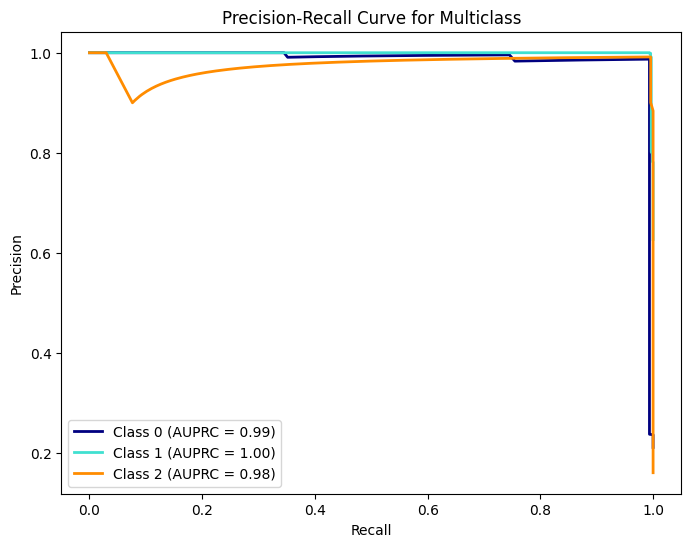


Average F1 Score: 0.8077791573368626


In [19]:
from sklearn.metrics import precision_recall_curve, auc, f1_score
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt

# Ensure labels are encoded for multiclass classification
y_test_encoded = label_binarize(y_test_actual, classes=[0, 1, 2])

# Calculate AUPRC for each class
precision = dict()
recall = dict()
auprc = dict()

# Create binary classifiers for each class
classifiers = OneVsRestClassifier(best_svc_classifier)

for i in range(len(label_mapping)):
    classifiers.fit(X_test, y_test_encoded[:, i])
    y_score = classifiers.decision_function(X_test)

    precision[i], recall[i], _ = precision_recall_curve(y_test_encoded[:, i], y_score)
    auprc[i] = auc(recall[i], precision[i])
    print("Average AUPRC score for ", i ," is: ", auprc[i])
# Plot Precision-Recall Curve for each class
plt.figure(figsize=(8, 6))
colors = ['navy', 'turquoise', 'darkorange']
for i, color in zip(range(len(label_mapping)), colors):
    plt.plot(recall[i], precision[i], color=color, lw=2,
             label='Class {0} (AUPRC = {1:0.2f})'
             ''.format(i, auprc[i]))

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Multiclass')
plt.legend(loc='best')
plt.show()

average_f1 = f1_score(y_test_actual, ensemble_preds_test, average='weighted')

print("\nAverage F1 Score:", average_f1)



The graph above shows an almost 1:1 mapping for all 3 labels, which means the rate for false positive, negative and neutral is less.

References:

---

[1] https://mlarchive.com/machine-learning/sentiment-analysis-with-random-forest/#:~:text=Sentiment%20Analysis%20with%20Random%20Forest,information%20from%20large%20textual%20datasets | Nora Yehia | 22 July 2023 | Sentiment Analysis with Random Forests


[2] https://medium.com/scrapehero/sentiment-analysis-using-svm-338d418e3ff1 |
Vasista Reddy | medium.com | Nov 12, 2018 | Sentiment Analysis using SVM

[3]
https://jictra.com.pk/index.php/jictra/article/view/276/138 |
Muhammad Faizan Siddiqui1, Faiza Iqbal2, Naveed Hussain | Sentiment Analysis on Twitter Data using MachineLearning Techniques | December 30, 2021 | Journal of Information Communication Technologies and Robotic Applications

[4] https://ieeexplore.ieee.org/abstract/document/9702681 |
G Prema Arokia Mary
; M S Hema; R Maheshprabhu; M Nageswara Guptha | Sentimental Analysis of Twitter Data using Machine Learning Algorithms | India | IEEE | 2021 International Conference on Forensics, Analytics, Big Data, Security (FABS)

[5] https://pypi.org/project/vaderSentiment/ |
Hutto, C.J. & Gilbert, E.E. (2014). VADER: A Parsimonious Rule-based Model for Sentiment Analysis of Social Media Text. Eighth International Conference on Weblogs and Social Media (ICWSM-14). Ann Arbor, MI, June 2014.

[6] https://scikit-learn.org/stable/auto_examples/model_selection/plot_precision_recall.html#:~:text=The%20precision%2Drecall%20curve%20shows,a%20low%20false%20negative%20rate |
Scikit-learn: Machine Learning in Python, Pedregosa et al., JMLR 12, pp. 2825-2830, 2011.

---
---
## Project 4: Time-serise dataset (70 marks)

The Weather dataset is a time-series dataset collected by a Raspberry Pi computer at a home in Newcastle. It contains a bunch of different features about the weather collected over an approximate 12-month period. The features are as follows:

| Column no | Feature                                                  |
|-----------|----------------------------------------------------------|
|         1 | Date and time in standard Linux format                   |
|         2 | Temperature from the first internal sensor (Celsius)     |
|         3 | Outside temperature (Celsius)                            |
|         4 | CPU Temperature (Celsius)                                |
|         5 | Count (always 1)                                         |
|         6 | Temperature from the second internal sensor (Celsius)    |
|         7 | Air Pressure (mmHg)                                      |
|         8 | Humidity (percentage)                                    |

Readings are measured in one-minute intervals between November 2021 and December 2022. Your task is to try and predict future values 5, 10, 15, 30 minutes into the future along with 1, 2, 6 and 12 hours into the future. I.e. given a time-sequence of measurements before 10:20am on Friday 3rd June 2022 how accurately can you predict the values for 10:25, 10:30, 10:35 and 10:50am and for 11:20, 12:20, 16:20 and 22:20. You can do this for any of the 6 weather features (not date or count). You should separate out a test set of the last 2 months of data (you need to have a continuous and separate test set to prevent leakage between training and testing).

The dataset can be downloaded from:
http://homepages.cs.ncl.ac.uk/stephen.mcgough/data/weather.csv

Some hints:
- There is some code below which shows you how to load and view the data to get you started.
- In order to score top marks for this dataset you should demonstrate multiple models, at least one of them should not use Deep Learning.
- To speed up your work here are some hints (assuming you’re using Colab):
 - Make sure you set the Runtime type to either GPU or TPU.
 - Copy the data to your Google drive so you don’t have to keep uploading it.
 - As the dataset is large you might want to do some of your initial testing on a subset of the data.

## Access to the files

The file is available from: http://homepages.cs.ncl.ac.uk/stephen.mcgough/data/log.txt

You can upload the file each time you use them, but this might take some time as they are quite large. An eisier option is to uploade them to a Google drive folder and mount this.

Full information on how to do this can be found at: https://colab.research.google.com/notebooks/io.ipynb

In the code below I have created a folder in Google drive called data and placed the file above in it.

In [ ]:
# to access google drive folder
from google.colab import drive
drive.mount('/content/drive') # When you run this you'll be prompted for a token - follow the link to generate this.

## Load the data

The data is stored in mumpy data files. You can use numpy.load() to read these in.

**Note: you'll need to change the location of the file to wherever you stored your files.**

In [ ]:
import numpy as np
from numpy import genfromtxt

data = genfromtxt('/content/drive/MyDrive/data/log.txt', delimiter=',')

In [ ]:
print(data)

## Data structure

The columns are:
0. Date and time
1. Inside temperature 1
2. Outside temperature
3. CPU Temperature
4. Count
5. Inside temperature 2
6. Air Pressure (mmHg)
7. Humidity (%)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

figure(figsize=(10, 10), dpi=80)

plt.plot(data[:, [1]])
plt.plot(data[:, [2]])
plt.plot(data[:, [3]])
plt.plot(data[:, [4]])
plt.plot(data[:, [5]])
plt.plot(data[:, [6]])
plt.plot(data[:, [7]])

## Your answer below